# Changes, rollback, and artifact provenance

CPU companion; no accelerator is required. TPU execution not validated.

- Separate content identity, validation evidence and active selection.
- Reject corrupt or failed artifacts before a pointer change.
- Rehearse a reversible local artifact selection and document its limits.

A new artifact is available, but which exact bytes are currently selected, and can we return to the previous valid version after a bad change? We will create content-addressed artifacts from an actual trained checkpoint, test a validation gate, atomically change one local selection pointer and rehearse rollback.

## The idea

Publishing an artifact and activating it are different operations. A content hash identifies a specific JSON payload, including its state and provenance. A small active pointer chooses which artifact a local consumer should use. Before changing that pointer we verify content integrity and required validation evidence. Rollback selects the previously recorded artifact through the same checks.

## A name is not a content identity

Filenames such as latest or final can be overwritten without revealing that the bytes changed. Our artifact ID is the SHA-256 digest of a canonical JSON encoding with sorted keys and nonfinite values rejected. Reordering dictionary insertion alone does not change that encoding. Changing a parameter, source hash or even a release note produces a different ID. This identity detects changed bytes; it does not prove that the artifact is correct or authorized.

## Attach enough provenance to reproduce the question

The artifact includes worker-source hash, training-configuration hash, data hash, full state and a validation record. These fields tie a claimed result to a concrete experiment. The local validation flag is a demonstration gate supplied by this trusted authoring workflow; it is not a signed attestation or protection against an adversarial publisher. A production registry needs access controls, trusted validators and policies appropriate to its use. Activation also independently evaluates the two model parameters on fixed held-out inputs $(-1.5,-0.37,0.22,1.5)$, using the known relationship $y=2x+1$. It requires mean squared error no larger than $1$. This intentionally permissive fixture gate checks that a changed model is actually evaluated; it is not a production quality threshold.

## Publish without affecting the current reader

publish writes a complete content-addressed file but does not create or change active.json. This permits inspection before use. activate reads that file, recomputes its digest and checks the gate before replacing the pointer. A failed gate leaves the current pointer byte-for-byte unchanged. The pointer contains current and previous IDs so an operator can identify what changed.

## Keep selection atomic and scope the guarantee

The atomic helper writes to a temporary sibling file, flushes and fsyncs it, then replaces the selected filename. The exercise has one writer and a local filesystem. It does not provide compare-and-swap against concurrent deployments, distributed consensus, atomic updates across multiple files or guaranteed power-loss durability. A multi-writer service must add a concurrency contract rather than assuming this example already supplies one.

## Rollback is another checked selection

Rollback reads the previous ID and calls the same activation path. It therefore rejects a previous artifact that has become corrupt. Selecting older weights does not undo external side effects, database migrations, changed data schemas or requests already served. Here the only changed operational state is a local pointer to a compatible JSON artifact. Describe that bounded result precisely.

## A change record should support diagnosis

Retain previous and candidate IDs, source/config/data hashes, the gate result, and why the change or rollback occurred. In this exercise the second valid artifact differs only in reviewed metadata, which makes the byte-level identity test unambiguous. The separate degraded-model experiment changes actual parameters and is rejected by the measured held-out gate; the accepted metadata revision is not claimed to improve predictions.

## Create the local artifact helpers

Create main.py with this block. Run python3 main.py in the CPU course environment.

In [1]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

The only filesystem writes are to the caller-selected run directory. Stable JSON encoding makes hashes reproducible.

## Define the supervised worker

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [2]:
# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

The string is a real Python program launched in a separate process. It emits structured events, synchronizes JAX updates and preserves complete state.

## Add bounded launch and result collection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [3]:
def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

The supervisor owns the child handle, captures its output and always waits for termination after a timeout.

## Add content-addressed publication and selection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [4]:
def publish(store, artifact):
    """Content-address one JSON artifact. Publishing does not activate it."""
    store=Path(store);identifier=digest(artifact)
    atomic_json(store/'artifacts'/(identifier+'.json'),artifact)
    return identifier


def read_artifact(store, identifier):
    if len(identifier) != 64 or any(c not in '0123456789abcdef' for c in identifier):
        raise ValueError('invalid artifact identifier')
    artifact=json.loads((Path(store)/'artifacts'/(identifier+'.json')).read_text())
    if digest(artifact) != identifier: raise ValueError('artifact digest mismatch')
    return artifact


def artifact_metrics(artifact):
    """Independent held-out arithmetic for this fixed linear-model release contract."""
    params=artifact.get('state',{}).get('params',[])
    if len(params)!=2 or any(not math.isfinite(float(v)) for v in params):
        raise ValueError('invalid model parameters')
    inputs=(-1.5,-.37,.22,1.5)
    mse=sum((params[0]*x+params[1]-(2*x+1))**2 for x in inputs)/len(inputs)
    return dict(held_out_mse=mse,acceptance_limit=1.,passed=mse<=1.)


def activate(store, identifier):
    artifact=read_artifact(store,identifier)
    if artifact.get('validation',{}).get('passed') is not True:
        raise ValueError('artifact has no passing validation evidence')
    required=['worker_hash','config_hash','data_hash','state']
    if any(name not in artifact for name in required): raise ValueError('artifact provenance incomplete')
    if not artifact_metrics(artifact)['passed']: raise ValueError('held-out model validation failed')
    previous=None;pointer=Path(store)/'active.json'
    if pointer.exists():previous=json.loads(pointer.read_text())['current']
    atomic_json(pointer,dict(current=identifier,previous=previous))
    return identifier


def rollback(store):
    pointer=json.loads((Path(store)/'active.json').read_text())
    if not pointer.get('previous'):raise ValueError('no previous version')
    return activate(store,pointer['previous'])

Publication and activation are separate; rollback uses the same integrity and validation checks.

## Rehearse a local release and rollback

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [5]:
with tempfile.TemporaryDirectory(prefix='ops-release-') as folder:
    base=Path(folder);run=launch(base/'run')
    state=json.loads((base/'run'/'checkpoint.json').read_text())
    store=base/'registry'
    artifact=dict(worker_hash=run['worker_hash'],config_hash=state['config_hash'],data_hash=state['data_hash'],state=state,validation={'passed':True,'check':'completed CPU fixture and checksum'})
    version_a=publish(store,artifact)
    assert not (store/'active.json').exists()
    activate(store,version_a)
    version_b=publish(store,dict(artifact,release_note='reviewed metadata revision'))
    activate(store,version_b)
    rejected=publish(store,dict(artifact,validation={'passed':False}))
    before=(store/'active.json').read_bytes()
    try: activate(store,rejected)
    except ValueError: rejected_without_change=(store/'active.json').read_bytes()==before
    else: raise AssertionError('bad release activated')
    assert rejected_without_change
    assert rollback(store)==version_a
    chosen=json.loads((store/'active.json').read_text())
    assert chosen['current']==version_a
print('first / second content IDs:',version_a,version_b)
print('failed gate kept selection:',rejected_without_change,'rollback restored first:',chosen['current']==version_a)

first / second content IDs: 26e4f003f57a71591febf8e34642c883762a0e82a49bd5beb92870d383f9a4d9 3a0b0f0490ee487522db673747bee44c4fbdeb9c2828686a5db5fce19ca7a3e4
failed gate kept selection: True rollback restored first: True


The artifact contains a checkpoint from an actual successful JAX job. The pointer changes only after its gate passes.

## Run the example

In [6]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

def publish(store, artifact):
    """Content-address one JSON artifact. Publishing does not activate it."""
    store=Path(store);identifier=digest(artifact)
    atomic_json(store/'artifacts'/(identifier+'.json'),artifact)
    return identifier


def read_artifact(store, identifier):
    if len(identifier) != 64 or any(c not in '0123456789abcdef' for c in identifier):
        raise ValueError('invalid artifact identifier')
    artifact=json.loads((Path(store)/'artifacts'/(identifier+'.json')).read_text())
    if digest(artifact) != identifier: raise ValueError('artifact digest mismatch')
    return artifact


def artifact_metrics(artifact):
    """Independent held-out arithmetic for this fixed linear-model release contract."""
    params=artifact.get('state',{}).get('params',[])
    if len(params)!=2 or any(not math.isfinite(float(v)) for v in params):
        raise ValueError('invalid model parameters')
    inputs=(-1.5,-.37,.22,1.5)
    mse=sum((params[0]*x+params[1]-(2*x+1))**2 for x in inputs)/len(inputs)
    return dict(held_out_mse=mse,acceptance_limit=1.,passed=mse<=1.)


def activate(store, identifier):
    artifact=read_artifact(store,identifier)
    if artifact.get('validation',{}).get('passed') is not True:
        raise ValueError('artifact has no passing validation evidence')
    required=['worker_hash','config_hash','data_hash','state']
    if any(name not in artifact for name in required): raise ValueError('artifact provenance incomplete')
    if not artifact_metrics(artifact)['passed']: raise ValueError('held-out model validation failed')
    previous=None;pointer=Path(store)/'active.json'
    if pointer.exists():previous=json.loads(pointer.read_text())['current']
    atomic_json(pointer,dict(current=identifier,previous=previous))
    return identifier


def rollback(store):
    pointer=json.loads((Path(store)/'active.json').read_text())
    if not pointer.get('previous'):raise ValueError('no previous version')
    return activate(store,pointer['previous'])

with tempfile.TemporaryDirectory(prefix='ops-release-') as folder:
    base=Path(folder);run=launch(base/'run')
    state=json.loads((base/'run'/'checkpoint.json').read_text())
    store=base/'registry'
    artifact=dict(worker_hash=run['worker_hash'],config_hash=state['config_hash'],data_hash=state['data_hash'],state=state,validation={'passed':True,'check':'completed CPU fixture and checksum'})
    version_a=publish(store,artifact)
    assert not (store/'active.json').exists()
    activate(store,version_a)
    version_b=publish(store,dict(artifact,release_note='reviewed metadata revision'))
    activate(store,version_b)
    rejected=publish(store,dict(artifact,validation={'passed':False}))
    before=(store/'active.json').read_bytes()
    try: activate(store,rejected)
    except ValueError: rejected_without_change=(store/'active.json').read_bytes()==before
    else: raise AssertionError('bad release activated')
    assert rejected_without_change
    assert rollback(store)==version_a
    chosen=json.loads((store/'active.json').read_text())
    assert chosen['current']==version_a
print('first / second content IDs:',version_a,version_b)
print('failed gate kept selection:',rejected_without_change,'rollback restored first:',chosen['current']==version_a)

first / second content IDs: 26e4f003f57a71591febf8e34642c883762a0e82a49bd5beb92870d383f9a4d9 3a0b0f0490ee487522db673747bee44c4fbdeb9c2828686a5db5fce19ca7a3e4
failed gate kept selection: True rollback restored first: True


Expected: Publishing leaves the active pointer unchanged. A failed validation gate cannot change it, and rollback selects the first verified content ID again.

## The selected artifact changes only after a passing gate

Predict: Should publishing or rejecting a candidate move the active selection?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [7]:
with tempfile.TemporaryDirectory() as folder:
    a=publish(folder,artifact);activate(folder,a)
    values=[1]
    b=publish(folder,dict(artifact,release_note='B'));values.append(1 if json.loads((Path(folder)/'active.json').read_text())['current']==a else 2)
    activate(folder,b);values.append(2 if json.loads((Path(folder)/'active.json').read_text())['current']==b else 1)
    bad=publish(folder,dict(artifact,validation={'passed':False}))
    try:activate(folder,bad)
    except ValueError:pass
    values.append(2 if json.loads((Path(folder)/'active.json').read_text())['current']==b else 1)
    rollback(folder);values.append(1 if json.loads((Path(folder)/'active.json').read_text())['current']==a else 2)
assert values==[1,1,2,2,1]
visual_data={'kind':'bar','labels':['activate A','publish B','activate B','reject candidate','rollback'],'xlabel':'executed local operation','ylabel':'selected artifact code: 1=A, 2=B','series':[{'label':'observed active pointer','y':values}]}

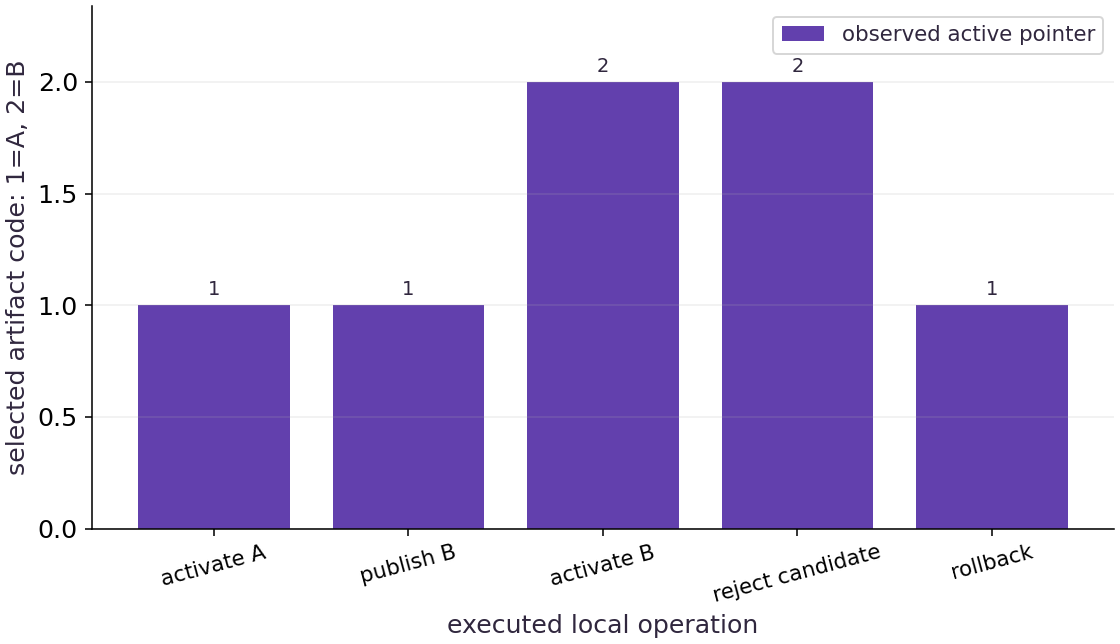

In [8]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories are actions in the executed local release drill. The vertical values are categorical codes: $1$ means artifact A and $2$ means artifact B. They are identifiers, not quality scores. The selected ID remains A after publishing B, changes to B after activation, stays B after a rejected candidate, and returns to A after rollback.

### Connect it to the computation

The flat pair around the rejected gate is the important invariant: failure must not partially change the active pointer. Every transition in the diagram is backed by a read of the local pointer in the figure experiment. The result proves a single-writer local selection workflow, not a multi-host rollout or rollback of external side effects.

## Identity follows content rather than key insertion order

Predict: Will dictionary key insertion order change the canonical content ID?

In [9]:
assert digest({'a':1,'b':2})==digest({'b':2,'a':1})
assert digest({'a':1,'b':2})!=digest({'a':1,'b':3})

Expected: Equivalent mappings share an ID; changed values do not.

Canonical encoding removes an incidental representation difference but preserves meaningful payload changes.

## Detect corruption before activation

Predict: What happens if the stored file no longer matches its content ID?

In [10]:
with tempfile.TemporaryDirectory() as folder:
    identifier=publish(folder,artifact)
    (Path(folder)/'artifacts'/(identifier+'.json')).write_text('{}')
    try: activate(folder,identifier)
    except ValueError as error: assert 'digest' in str(error)
    else: raise AssertionError('corruption accepted')
    assert not (Path(folder)/'active.json').exists()

Expected: The corrupted artifact is rejected before any pointer appears.

A filename containing a hash is not enough: the reader must recompute and compare the payload digest.

## Reject an actually degraded model

Predict: Can a candidate with a claimed passing flag bypass the measured quality gate?

In [11]:
with tempfile.TemporaryDirectory() as folder:
    stable=publish(folder,artifact);activate(folder,stable)
    degraded=dict(artifact,state=dict(artifact['state'],params=[100.,-100.]))
    candidate=publish(folder,degraded)
    assert artifact_metrics(degraded)['held_out_mse'] > 1.
    before=(Path(folder)/'active.json').read_bytes()
    try:activate(folder,candidate)
    except ValueError as error:assert 'held-out' in str(error)
    else:raise AssertionError('degraded model activated')
    assert before==(Path(folder)/'active.json').read_bytes()

Expected: The known held-out relationship detects the changed model despite its passing claim.

Measured validation and claimed validation are distinct. The local gate recomputes the prediction error before selection.

## Your exercise

Publish two compatible validated artifacts that differ in an explicit release note. Activate both in sequence, then rollback and verify the exact selected ID and content.

In [12]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [13]:
with tempfile.TemporaryDirectory() as folder:
    one=publish(folder,dict(artifact,release_note='candidate one'))
    two=publish(folder,dict(artifact,release_note='candidate two'))
    activate(folder,one);activate(folder,two)
    assert rollback(folder)==one
    assert read_artifact(folder,one)['release_note']=='candidate one'

## Reject an incomplete provenance record · Transfer / diagnosis

Construct a payload claiming passing validation but lacking the worker-source hash. Verify that it cannot become active.

Hint: A boolean flag does not replace required source/config/data evidence.

In [14]:
# Write your attempt here.

## Reference reasoning

The gate establishes only the declared local contract; it still does not authenticate who supplied those claims.

In [15]:
with tempfile.TemporaryDirectory() as folder:
    incomplete=dict(artifact);del incomplete['worker_hash']
    identifier=publish(folder,incomplete)
    try: activate(folder,identifier)
    except ValueError: pass
    else: raise AssertionError('missing provenance accepted')

## Check rollback without history · Transfer / diagnosis

Attempt rollback before any previous artifact exists, then verify the first activation remains selected.

Hint: A failed rollback must not clear the current selection.

In [16]:
# Write your attempt here.

## Reference reasoning

A runbook needs a defined failure path when no compatible previous version is available.

In [17]:
with tempfile.TemporaryDirectory() as folder:
    identifier=publish(folder,artifact);activate(folder,identifier)
    before=(Path(folder)/'active.json').read_bytes()
    try: rollback(folder)
    except ValueError: pass
    else: raise AssertionError('invented rollback history')
    assert before==(Path(folder)/'active.json').read_bytes()

## Checkpoint

What does a matching artifact digest establish?

1. The payload matches its recorded content identity
2. The model is accurate on all future data
3. The publisher is authenticated and authorized

## Diagnose

If a candidate cannot activate, distinguish a digest mismatch, missing provenance and a failed quality gate. Do not repair a corrupt payload by renaming it to its newly computed hash without understanding the change. If rollback fails, verify that previous content still exists and remains compatible before editing the selection pointer.

## Evidence

Keep source/configuration/data hashes, actual held-out candidate predictions, the rejected degraded release and unchanged active pointer, followed by verified rollback.

## Carry forward

- Content identity, validation and activation answer separate questions.
- Rollback must be rehearsed against the actual selection and compatibility contracts.

## Primary references

- [Python subprocess management](https://docs.python.org/3/library/subprocess.html)
- [Python os.replace and fsync](https://docs.python.org/3/library/os.html#os.replace)
- [JAX asynchronous dispatch and synchronization](https://docs.jax.dev/en/latest/async_dispatch.html)
- [JAX device discovery](https://docs.jax.dev/en/latest/_autosummary/jax.devices.html)